##### Ссылка на репозиторий и этот ноутбук с файлами: github: https://github.com/randnull/genotec/blob/main/hw_3_admixture.ipynb

Домашнее задание 3

После установки [plink 1.9](https://www.cog-genomics.org/plink/) и скачивания файла с геномами (папка data) c http://www.russiangenome.ru/ выполнил команды

1. LD-pruning

Возьмем размер окна 50, шаг в 5, а порог $r^2$=0.2

```bash
plink --bfile biengi/biengi --indep-pairwise 50 5 0.2 --out data/biengi_pruned
```

Теперь наши данные очищены от избыточности для корректного PCA

По выходе мы получаем 3 файла:
- логи 
- *.prune.in (то, что мы оставляем)
- *.prune.out (то, что изыточно)

2. Очистим оригинальный файл и создадим версию без избыточности:

```bash
plink --bfile biengi/biengi --extract biengi_pruned.prune.in --make-bed --out biengi_ldpruned
```

## С помощью PLINK посчитайте и визуализируйте матрицу с FST

Для того, чтобы применить FST, нам необходима таблица формата

FID, IID, Population

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import subprocess, os, pathlib, re
from tqdm import tqdm

In [2]:
pedind = pd.read_csv(
    "data/biengi/biengi.pedind",
    sep="\t",
    header=None,
    names=["FID", "IID", "nm2", "nm1", "sex", "Population"],
)

clusters = pedind[["FID", "IID", "Population"]]
clusters.to_csv("data/biengi_clusters.txt", sep="\t", index=False)

clusters.head()

,FID,IID,Population
0,4461875510_R01C01,4461875510_R01C01,Karel
1,4461875510_R01C02,4461875510_R01C02,Karel
2,4461875510_R02C01,4461875510_R02C01,Karel
3,4461875513_R02C02,4461875513_R02C02,Karel
4,4461875513_R01C02,4461875513_R01C02,Karel


Теперь мы можем запустить FST через plink.

```bash
plink2 --bfile data/biengi_ldpruned --pheno data/biengi_clusters.txt --pheno-name Population --fst Population method=hudson --out data/biengi_fst
```

Визуализируем полученные данные

In [53]:
pairs = pd.read_csv("data/biengi_fst.fst.summary", sep="\t")
pairs.columns = ["population1", "population2", "fst"]

populations = sorted(set(pairs["population1"]) | set(pairs["population2"]))
population_len = len(populations)

fst = pd.DataFrame(np.zeros((population_len, population_len)), index=list(populations), columns=list(populations))

for i, j in pairs.iterrows():
    fst.loc[j.population1, j.population2] = j.fst
    fst.loc[j.population2, j.population1] = j.fst

fst

,Abkhaz,Adygei,Bashkir,Belarus,Buryat,Chechen,Cherkes,Chinese,Chuvash,Kabardin,...,Moldovan,Mordva,Russian_NSK,Russian_STV,Tatar,Tuva,Udmurt,Ukrainian,Uzbek,Yakut
Abkhaz,0.000000,0.003319,0.026265,0.015076,0.071396,0.006419,0.002364,0.096535,0.019941,0.001959,...,0.010436,0.014344,0.013786,0.015143,0.012398,0.068666,0.026684,0.013155,0.020102,0.086141
Adygei,0.003319,0.000000,0.023369,0.012891,0.067311,0.007191,0.002173,0.092642,0.017287,0.001917,...,0.009381,0.012233,0.011523,0.012735,0.010283,0.064790,0.023989,0.011436,0.017892,0.081902
Bashkir,0.026265,0.023369,0.000000,0.022091,0.026937,0.024376,0.018334,0.047923,0.009747,0.018026,...,0.021549,0.016309,0.014533,0.015826,0.008353,0.024372,0.014614,0.020629,0.005670,0.037454
Belarus,0.015076,0.012891,0.022091,0.000000,0.071503,0.013742,0.010431,0.098741,0.011362,0.010098,...,0.002413,0.001956,0.001335,0.001847,0.005246,0.068544,0.019019,0.000321,0.022072,0.086256
Buryat,0.071396,0.067311,0.026937,0.071503,0.000000,0.068750,0.059749,0.022462,0.044739,0.059564,...,0.069373,0.061103,0.058573,0.060836,0.045561,0.010819,0.049343,0.069565,0.023461,0.016620
Chechen,0.006419,0.007191,0.024376,0.013742,0.068750,0.000000,0.005608,0.094323,0.018008,0.004902,...,0.010335,0.012703,0.012278,0.013439,0.011040,0.065905,0.024245,0.012087,0.018837,0.083476
Cherkes,0.002364,0.002173,0.018334,0.010431,0.059749,0.005608,0.000000,0.084245,0.013255,0.000410,...,0.007338,0.009270,0.008627,0.009779,0.006930,0.057204,0.019918,0.008907,0.013255,0.074045
Chinese,0.096535,0.092642,0.047923,0.098741,0.022462,0.094323,0.084245,0.000000,0.069896,0.084228,...,0.096034,0.087791,0.084849,0.087880,0.070181,0.024338,0.075067,0.096899,0.039107,0.031226
Chuvash,0.019941,0.017287,0.009747,0.011362,0.044739,0.018008,0.013255,0.069896,0.000000,0.012943,...,0.012128,0.007918,0.006539,0.007370,0.003487,0.041505,0.012008,0.010314,0.011021,0.056532
Kabardin,0.001959,0.001917,0.018026,0.010098,0.059564,0.004902,0.000410,0.084228,0.012943,0.000000,...,0.006566,0.008903,0.008122,0.009581,0.006405,0.057048,0.019608,0.008523,0.012756,0.073756


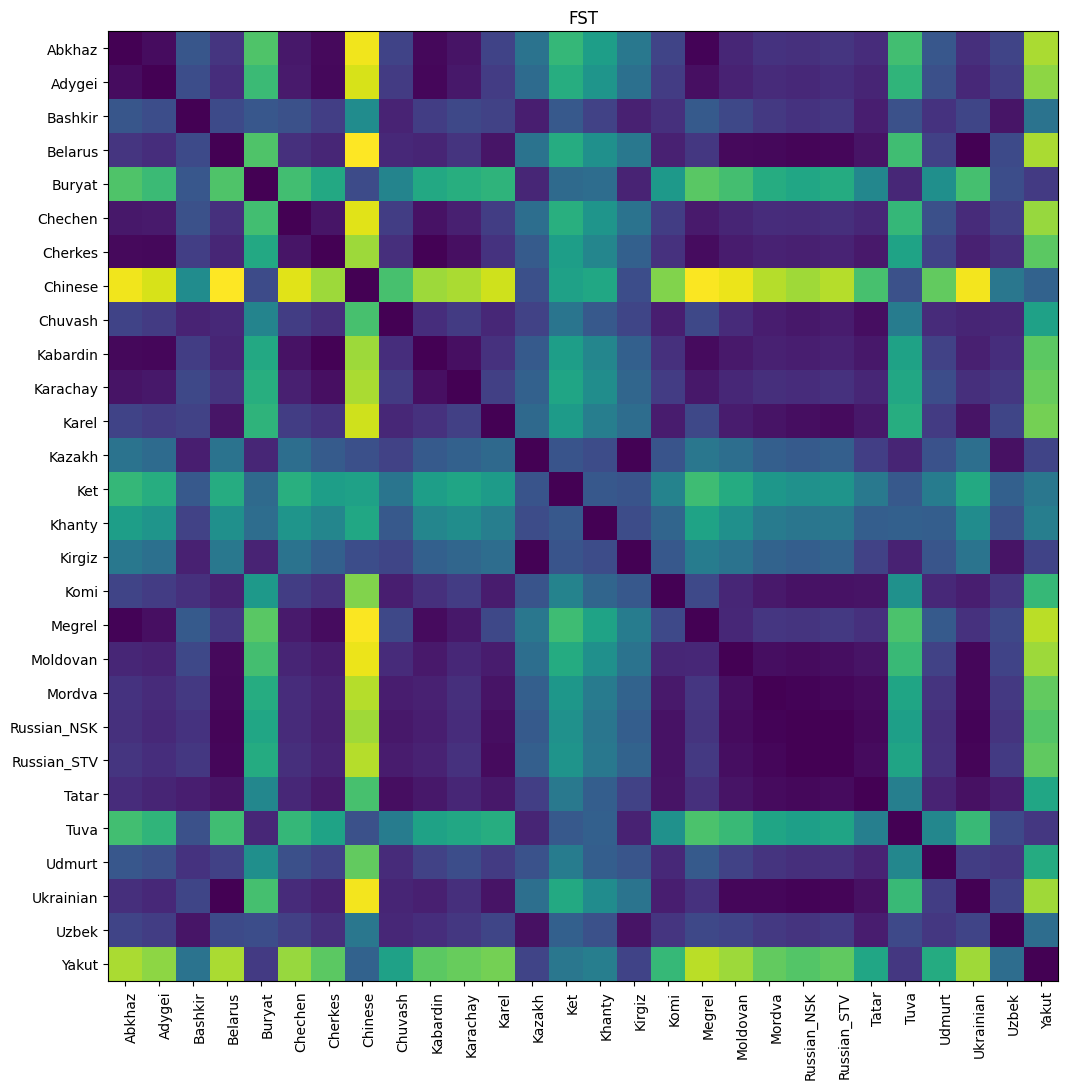

In [54]:
fig, ax = plt.subplots(figsize=(11, 11))
im = ax.imshow(fst.values)

ax.set_xticks(range(len(populations)), labels=populations,
              rotation=90, ha="right", rotation_mode="anchor")
ax.set_yticks(range(len(populations)), labels=populations)

ax.set_title("FST")
fig.tight_layout()
plt.show()

Китайцы и якуты сильнее всего отличаются от всех остальных. Остальные популяции имеют общие части

## Используйте инструмент ADMIXTURE, чтобы получить ADMIXTURE-plot

Для этого установим [бинарник admixture](https://dalexander.github.io/admixture/download.html) и запустим алгоритм для разных K

## Какой вы выбрали? Обоснуйте

K (число изначальных популяций внутри каждой популяции) это не обучаемый параметр.

Мы возьмем разумные число K от 2 до 5 (так как все геномы +- с одной большой области на карте) и посмотрим на скоры кросс валидации, выберем лучший.

Для этого запустим алгоритм для разных K

In [ ]:
out_dir = pathlib.Path("data/admixture")
out_dir.mkdir(parents=True, exist_ok=True)
input_file = os.path.abspath("data/biengi_ldpruned.bed")

K_grid = [2, 3, 4, 5]

for k in tqdm(K_grid):
    log_path = out_dir / f"log_admixture{k}.out"
    print('current k:', k)
    with open(log_path, "w") as f:
        proc = subprocess.Popen(
            ["admixture", "--cv", "-j13", input_file, str(k)],
            cwd=out_dir,
            stdout=subprocess.PIPE,
            text=True, 
        )
        for i, o in enumerate(proc.stdout):
            f.write(o)
            if "Loglikelihood" in o and i%11 == 0: 
                print(o, "\n")

        proc.wait()
    print(f"done for k = {k} ({proc.returncode})")

  0%|          | 0/4 [00:00<?, ?it/s]

current k: 2
10 (QN/Block) 	Elapsed: 22.914	Loglikelihood: -7.40186e+07	(delta): 0.422623
 

21 (QN/Block) 	Elapsed: 24.5	Loglikelihood: -7.40186e+07	(delta): 0.329113
 

32 (QN/Block) 	Elapsed: 22.903	Loglikelihood: -7.40186e+07	(delta): 0.000216946
 



 25%|██▌       | 1/4 [19:38<58:54, 1178.00s/it]

done for k = 2 (0)
current k: 3
10 (QN/Block) 	Elapsed: 21.67	Loglikelihood: -7.37549e+07	(delta): 248.861
 

21 (QN/Block) 	Elapsed: 22.808	Loglikelihood: -7.37542e+07	(delta): 0.967701
 



 50%|█████     | 2/4 [39:36<39:40, 1190.29s/it]

done for k = 3 (0)
current k: 4
10 (QN/Block) 	Elapsed: 22.385	Loglikelihood: -7.35868e+07	(delta): 1004.52
 

21 (QN/Block) 	Elapsed: 22.415	Loglikelihood: -7.35837e+07	(delta): 50.9229
 

32 (QN/Block) 	Elapsed: 22.504	Loglikelihood: -7.35835e+07	(delta): 14.4646
 

43 (QN/Block) 	Elapsed: 22.45	Loglikelihood: -7.35834e+07	(delta): 1.4734
 

54 (QN/Block) 	Elapsed: 23.258	Loglikelihood: -7.35834e+07	(delta): 0.191568
 

65 (QN/Block) 	Elapsed: 22.565	Loglikelihood: -7.35834e+07	(delta): 0.00117381
 



 75%|███████▌  | 3/4 [1:15:37<27:13, 1633.33s/it]

done for k = 4 (0)
current k: 5
10 (QN/Block) 	Elapsed: 23.908	Loglikelihood: -7.34888e+07	(delta): 2864.68
 

21 (QN/Block) 	Elapsed: 24.122	Loglikelihood: -7.3474e+07	(delta): 208.827
 

32 (QN/Block) 	Elapsed: 24.064	Loglikelihood: -7.34726e+07	(delta): 15.9763
 

43 (QN/Block) 	Elapsed: 24.069	Loglikelihood: -7.34724e+07	(delta): 0.876623
 

54 (QN/Block) 	Elapsed: 24.111	Loglikelihood: -7.34724e+07	(delta): 0.0149622
 

Loglikelihood: -73472421.428250
 



100%|██████████| 4/4 [1:50:04<00:00, 1651.10s/it]

done for k = 5 (0)


Посмотрим на наши скоры CV

CV error (K=2): 0.55727

CV error (K=3): 0.55486

CV error (K=4): 0.55393

CV error (K=5): 0.55424

Как видно из CV score, лучший скор вышел при K=4. В целом это логично предположить, учитывая то, что все геномы взяты из одной области

Теперь нужно посторить admixture_plot

Для этого прочитаем наши данные (они идут без обозначений и id, поэтому возьмем порядок и id из файлов plink (fam и pedind))

Отсоритируем для хорошей картинки (одни популяции идут рядом)

In [49]:
def create_admixture_plot(k):
    Q = pd.read_csv(f"data/admixture/biengi_ldpruned.{k}.Q", sep=r"\s+", header=None)
    Q.columns = [f"pop{i+1}" for i in range(k)]

    fam = pd.read_csv("data/biengi_ldpruned.fam", sep=r"\s+", header=None, names=["FID","IID","x","y","sex","Population"])
    pedind = pd.read_csv("data/biengi/biengi.pedind", sep="\t", header=None, names=["FID","IID","x","y","sex","Population"])
    df = (fam[["IID"]].merge(pedind[["IID","Population"]], on="IID", how="left").join(Q))
    df = df.sort_values("Population").reset_index(drop=True)
    
    plt.figure(figsize=(20, 4))
    bottom = np.zeros(len(df))

    for i in range(k):
        plt.bar(range(len(df)), df[f"pop{i+1}"], bottom=bottom, width=1)
        bottom += df[f"pop{i+1}"].values

    positions, labels = [], []
    boundaries = []
    for pop, grp in df.groupby("Population", sort=False):
        positions.append(np.mean(grp.index))
        labels.append(pop)
        boundaries.append(grp.index.max() + 0.5)

    for b in boundaries[:-1]:
        plt.axvline(b, color="white", linewidth=1)

    plt.xticks(positions, labels, rotation=90)
    plt.xlim(-0.5, len(df) - 0.5)
    plt.ylim(0, 1)
    plt.ylabel("Ancestry proportion")
    plt.title(f"ADMIXTURE (k = {k})")
    plt.tight_layout()
    plt.show()

Визуализируем наш график ADMIXTURE-plot

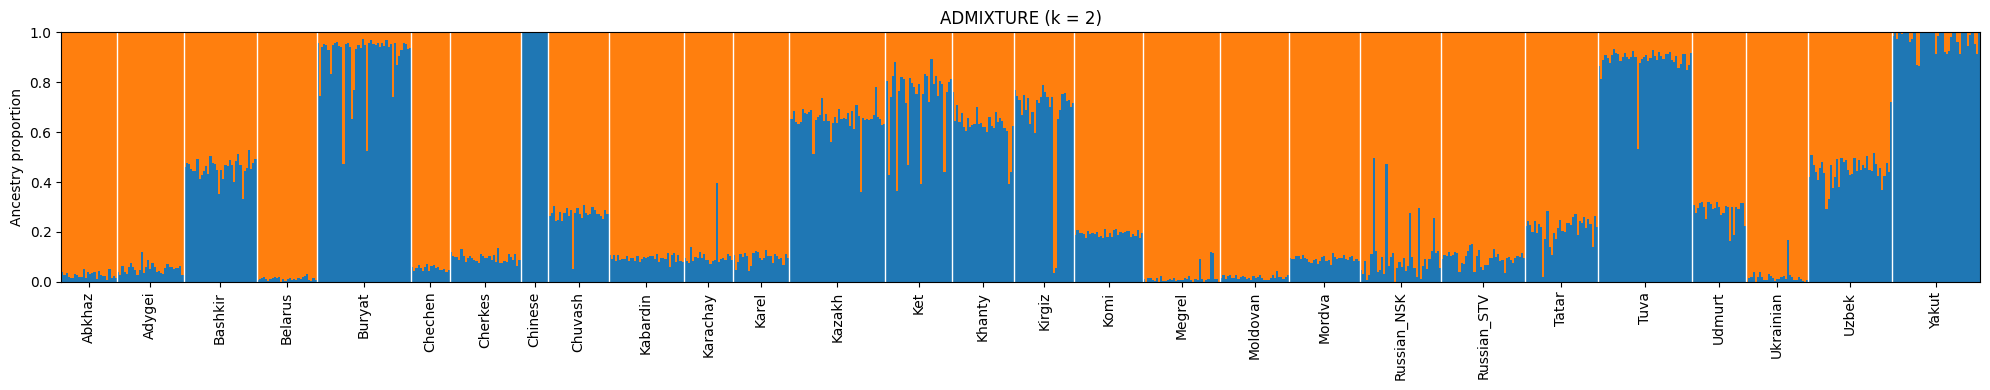

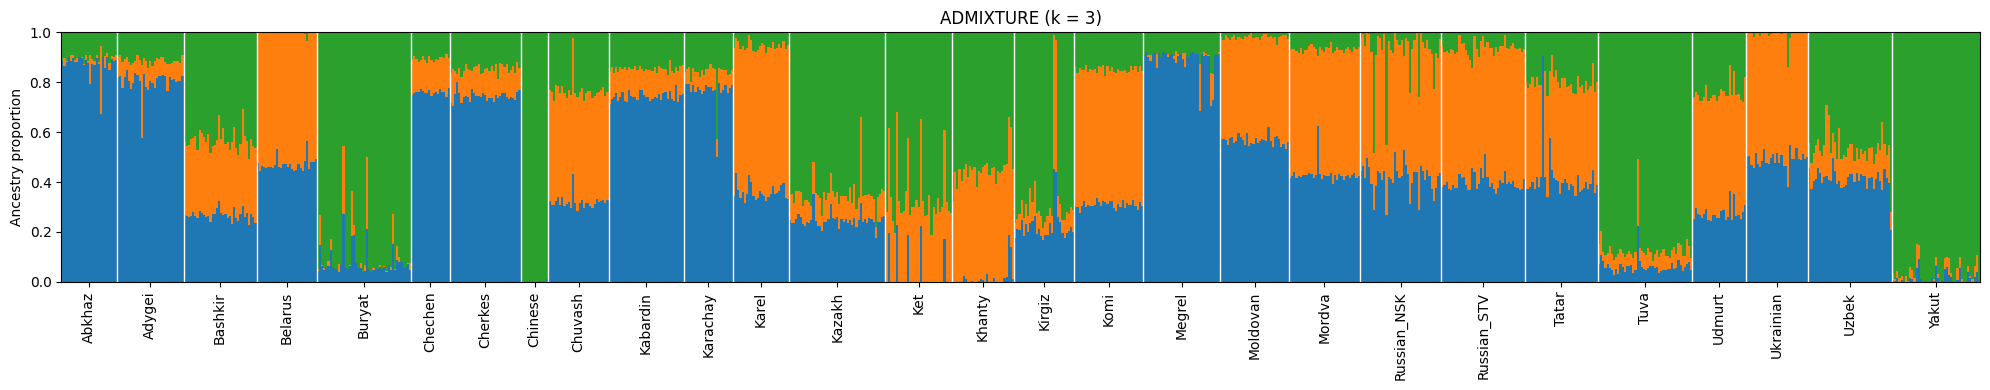

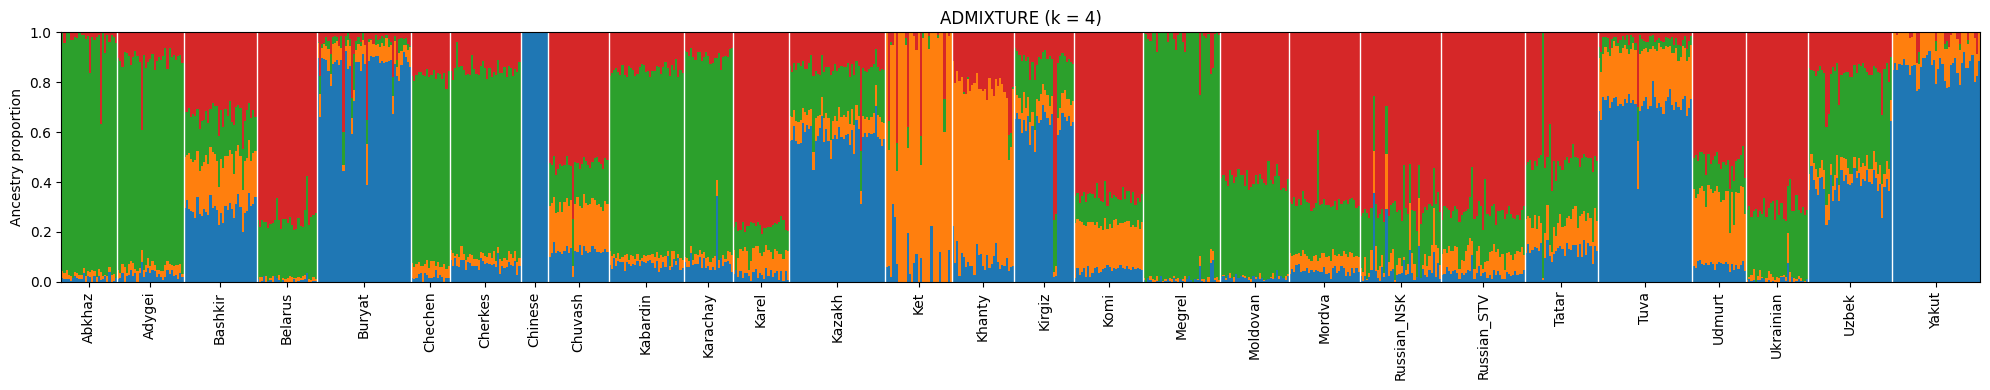

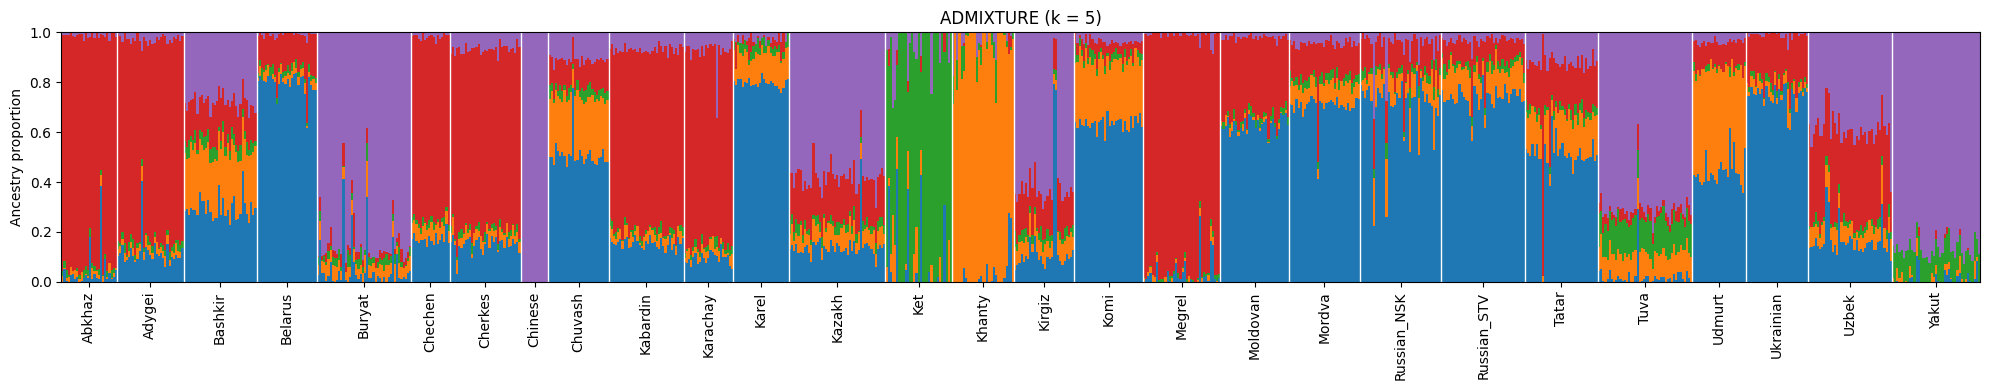

In [50]:
for k in range(2, 6):
    create_admixture_plot(k)

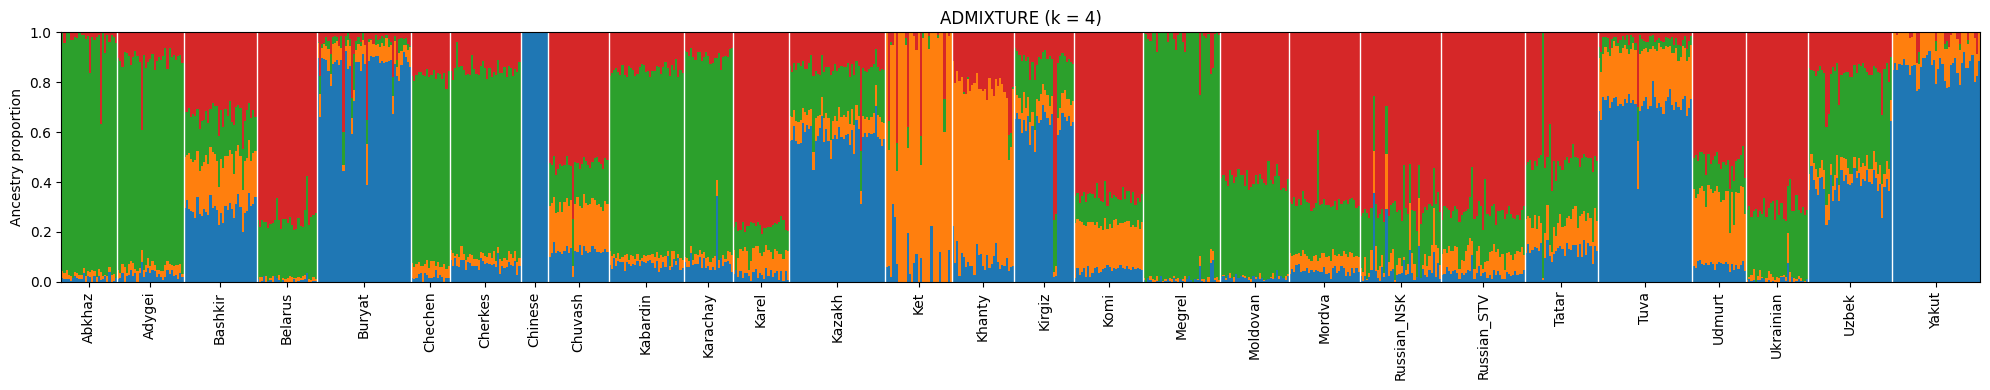

In [52]:
create_admixture_plot(4)

## Проанализируйте ADMIXTURE-plot? Соответствует ли он Вашим представлениям о древних донорских популяциях, сформировавших современные? Сравните результаты с PCA из предыдущего домашнего задания.

Видно, что у русских, белорусов и украинцев примерно похожий состав (в основном у русских больше "синей" популяции).

Китай был достаточно закрытой страной и не вели кочевой образ жизни, поэтому у них нет примесей, кроме одного происхождения.

Коми по происхождению это финно-угорский народ (то есть объясняется, почему у них сильное разбиение на разные составы).

Из всего этого можно сделать вывод, что он примерно соответсвует представлениям о происхождении древных донорских популяций

Для ответа на второй вопрос, приведем график PCA из предыдущего задания

![PCA](graph/pca.png)

Также видно, что китайцы (слева, снизу) действительно стоят отдельно от остальных популяций, однако якуты на картинке смешиваются с 2мя другими популяциями.

Русский, белорусы и украинцы также рядом, что и соотносится с ADMIXTURE.

Разные методы показывают примерно схожий результат (соотносятся)